In [50]:
import pandas as pd
import matplotlib.pyplot as plt

fifa = pd.read_csv('data/fifa_data.csv')

fifa.head()

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,0,158023,L. Messi,31,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94,94,FC Barcelona,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,1,20801,Cristiano Ronaldo,33,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Juventus,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,2,190871,Neymar Jr,26,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,93,Paris Saint-Germain,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,3,193080,De Gea,27,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91,93,Manchester United,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,4,192985,K. De Bruyne,27,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91,92,Manchester City,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


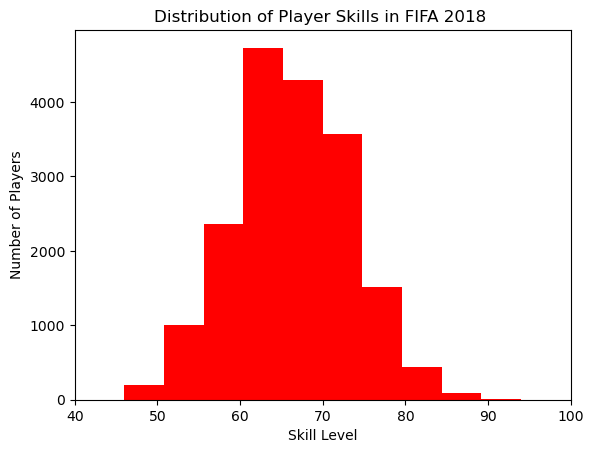

In [51]:
bins = [40,50,60,70,80,90,100]
plt.hist(fifa.Overall, color='red')
plt.xticks(bins) # bins means range
plt.xlabel('Skill Level')
plt.ylabel('Number of Players')
plt.title('Distribution of Player Skills in FIFA 2018 ')
plt.savefig('outputs/fifa_histo.png',dpi=300)
plt.show()

Pie Charts

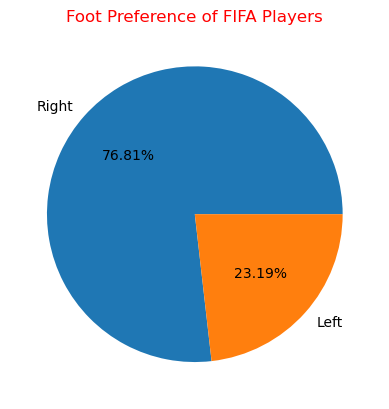

In [52]:
Left_foot = fifa['Preferred Foot'].value_counts()
plt.pie(Left_foot, labels=Left_foot.index, autopct='%.2f%%')
plt.title('Foot Preference of FIFA Players', color = 'red')
plt.savefig('outputs/Pie_chart.png',dpi =300)
plt.show()

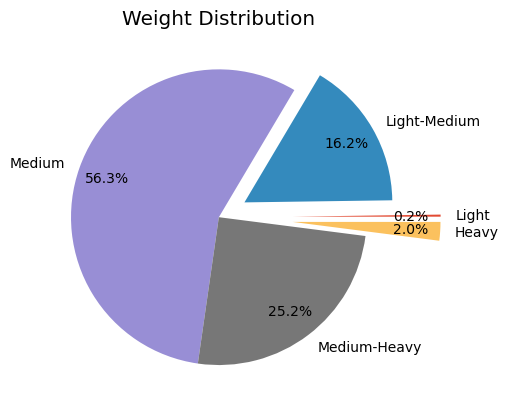

In [53]:
plt.style.use('ggplot')

fifa['Weight'] = pd.to_numeric(
    fifa['Weight'].astype(str).str.replace('lbs', ''),  # here we convert weight to all strings first and replace the string 'lbs' with nothing  so u can say our value become like '159' but still it is in string so we use pd.to_numeric 
    errors='coerce' # we use coerce bcz we dont want null values to cause an issue 
)
bins = [0, 125, 150, 175, 200, float('inf')]
labels = ['Light', 'Light-Medium', 'Medium', 'Medium-Heavy', 'Heavy']


fifa['Weight_Category'] = pd.cut(fifa['Weight'], bins=bins, labels=labels) # bins and labels are parameters for pd.cut

counts = fifa['Weight_Category'].value_counts().sort_index()

explode = (.5,.2,0,0,.5)

plt.pie(counts, labels=counts.index, autopct='%.1f%%' , pctdistance=0.8 , explode= explode)
plt.title('Weight Distribution')
plt.savefig('outputs/pie2.png',dpi = 300)
plt.show()

/var/folders/6r/86tcndg55p115rtqt5q8jrj00000gn/T/ipykernel_2160/3008590228.py:11: MatplotlibDeprecationWarning: Passing the notch parameter of boxplot() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.boxplot(fifa.Club,fifa[teams], label=teams)


TypeError: can only concatenate str (not "float") to str

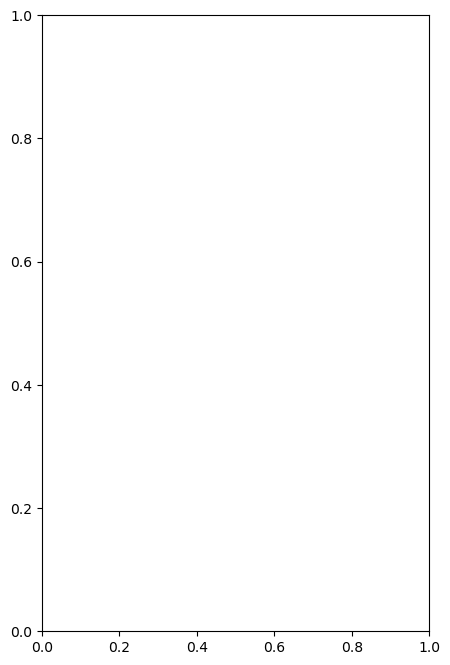

In [ ]:
plt.style.use('default')

plt.figure(figsize=(5,8))

barcelona = fifa.loc[fifa.Club == 'FC Barcelona']['Overall']
madrid = fifa.loc[fifa.Club == 'Real Madrid']['Overall']
revs = fifa.loc[fifa.Club == 'New England Revolution']['Overall']


plt.title('Professional Soccer Team Comparison')

labels = ['FC Barcelona', 'Real Madrid','NE Revolution']
plt.ylabel ('FIFA Overall Rating')
plt.boxplot([barcelona, madrid, revs],labels=labels)
plt.show()